# Notebook 08 — Model Explainability

Interpret the trained market value prediction model using SHAP.

## 1. Imports ##

In [21]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap
import joblib

## 2. Directories ##

In [22]:
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load Model ##

In [23]:
model = joblib.load(
    MODELS_DIR / "random_forest_market_value.pkl"
)

## 4. DuckDB Connection ##

In [24]:
con = duckdb.connect()

con.execute("PRAGMA threads=8")

PARQUET = PROCESSED_DATA_DIR / "players_clean"

## 5. Load Explainability Dataset ##

In [25]:
explain_df = con.sql(f"""
SELECT

TRY_CAST(age AS DOUBLE) AS age,
TRY_CAST(overall AS DOUBLE) AS overall,
TRY_CAST(potential AS DOUBLE) AS potential,
TRY_CAST(pace AS DOUBLE) AS pace,
TRY_CAST(shooting AS DOUBLE) AS shooting,
TRY_CAST(passing AS DOUBLE) AS passing,
TRY_CAST(dribbling AS DOUBLE) AS dribbling,
TRY_CAST(defending AS DOUBLE) AS defending,
TRY_CAST(physic AS DOUBLE) AS physic,
TRY_CAST(wage_eur AS DOUBLE) AS wage

FROM parquet_scan('{PARQUET}')

WHERE

TRY_CAST(age AS DOUBLE) IS NOT NULL
AND TRY_CAST(overall AS DOUBLE) IS NOT NULL
AND TRY_CAST(potential AS DOUBLE) IS NOT NULL
AND TRY_CAST(pace AS DOUBLE) IS NOT NULL
AND TRY_CAST(shooting AS DOUBLE) IS NOT NULL
AND TRY_CAST(passing AS DOUBLE) IS NOT NULL
AND TRY_CAST(dribbling AS DOUBLE) IS NOT NULL
AND TRY_CAST(defending AS DOUBLE) IS NOT NULL
AND TRY_CAST(physic AS DOUBLE) IS NOT NULL
AND TRY_CAST(wage_eur AS DOUBLE) IS NOT NULL

USING SAMPLE 10000 ROWS
""").df()

## 6. Feature Matrix ##

In [26]:
X = explain_df.copy()

## 7. Create SHAP Explainer ##

In [27]:
explainer = shap.TreeExplainer(model)

## 8. Compute SHAP Values ##

In [28]:
explainer = shap.TreeExplainer(model)

# Returns a shap.Explanation object
shap_values = explainer(X)

## 9. SHAP Summary Plot ##

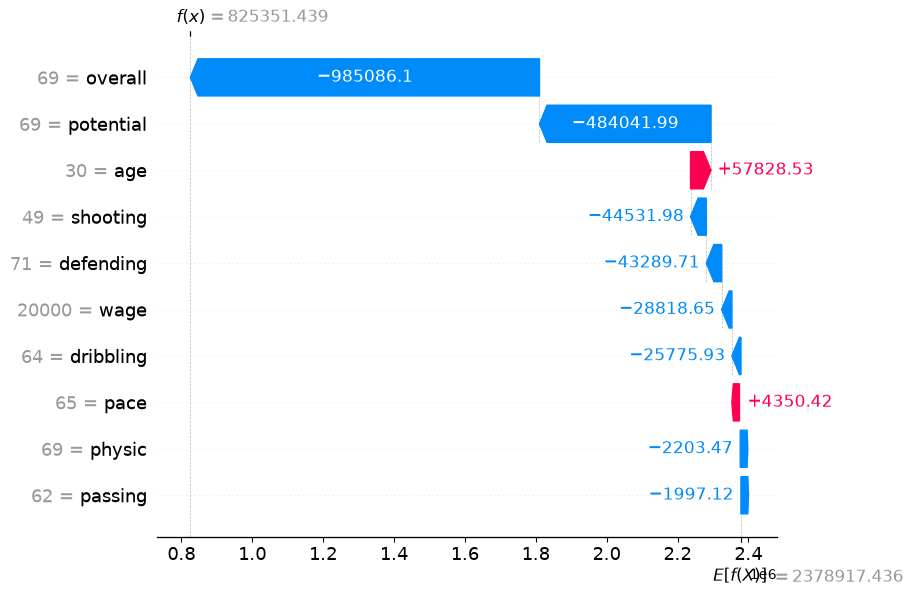

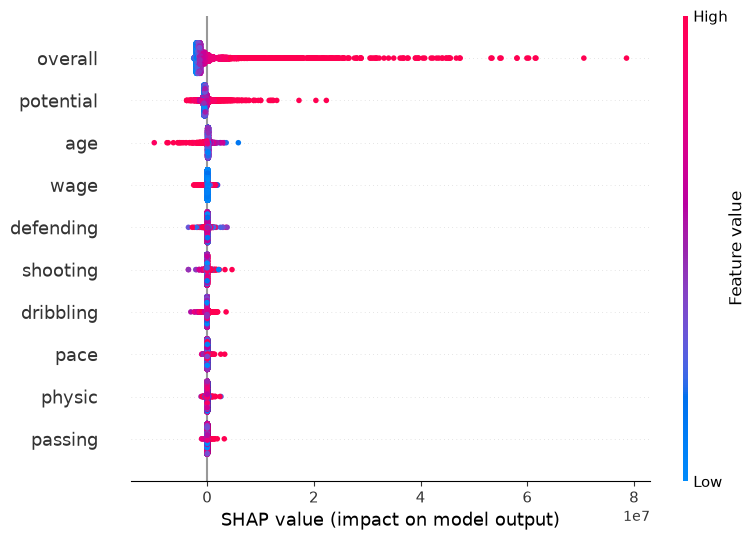

In [30]:
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 10. SHAP Bar Plot ##

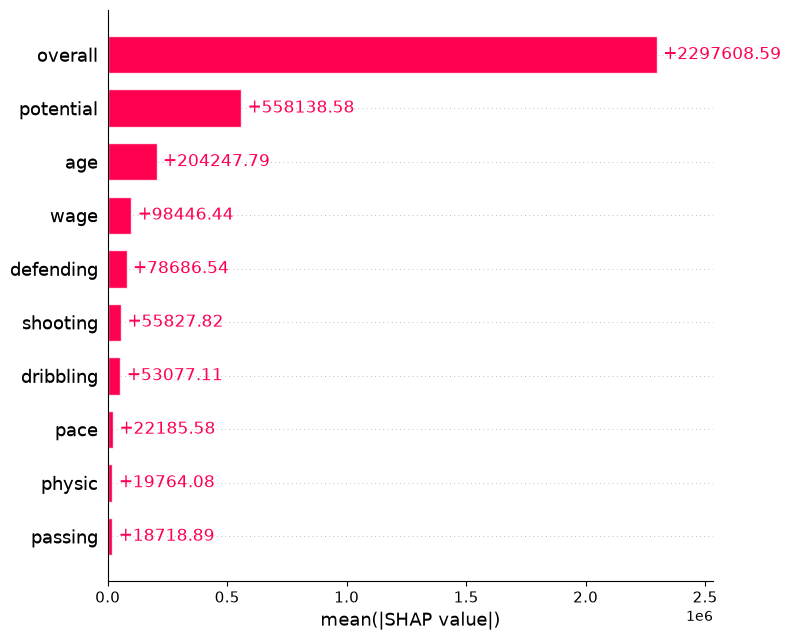

In [31]:
plt.figure(figsize=(10, 7))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 11. Explain One Player ##

In [32]:
sample_player = X.iloc[[0]]

sample_shap = explainer.shap_values(sample_player)

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    sample_shap[0],
    sample_player,
)

## 12. SHAP Waterfall Plot ##

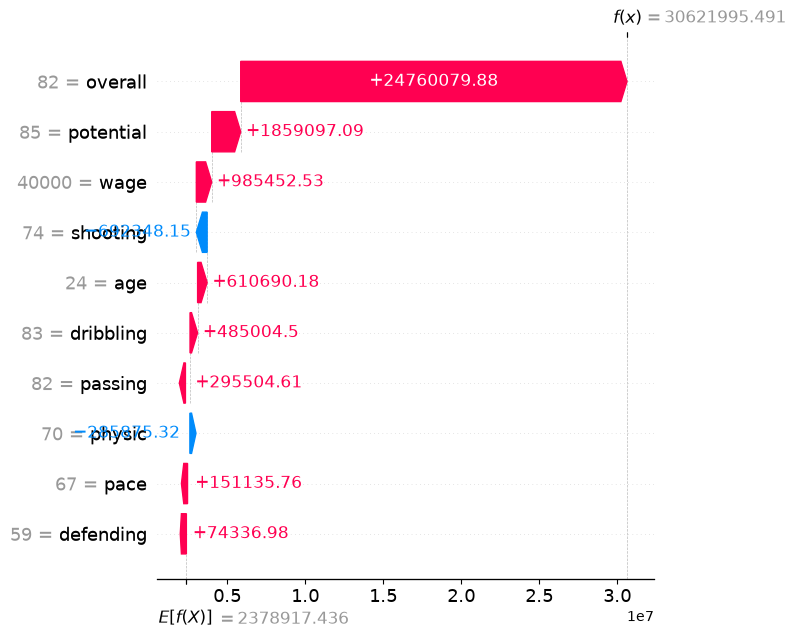

In [34]:
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    shap_values[0],
    max_display=15,
    show=False,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "waterfall_player_0001.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 12.1 SHAP Multiple Waterfall Plots ##

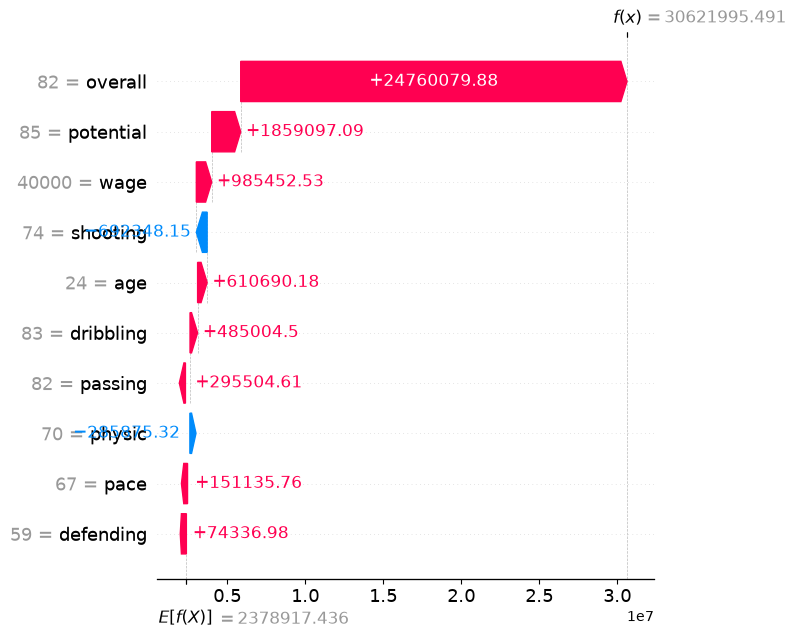

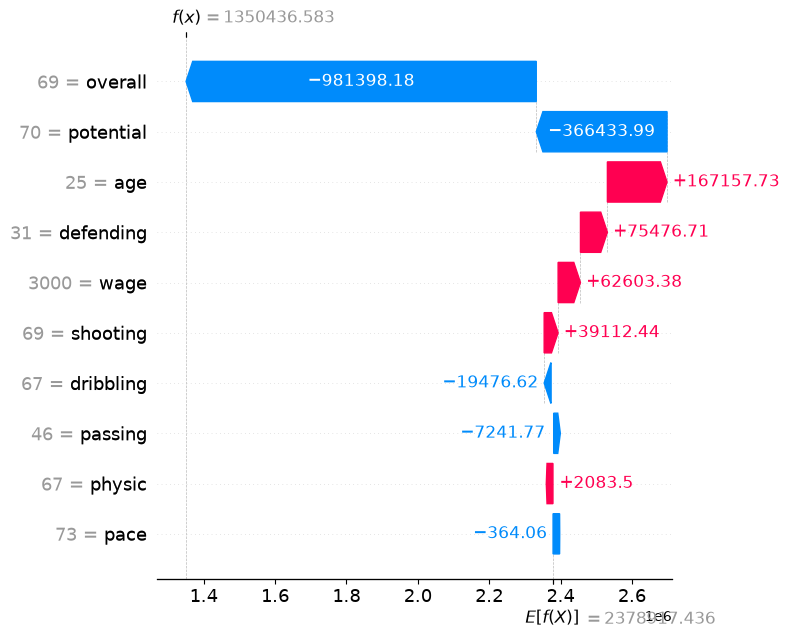

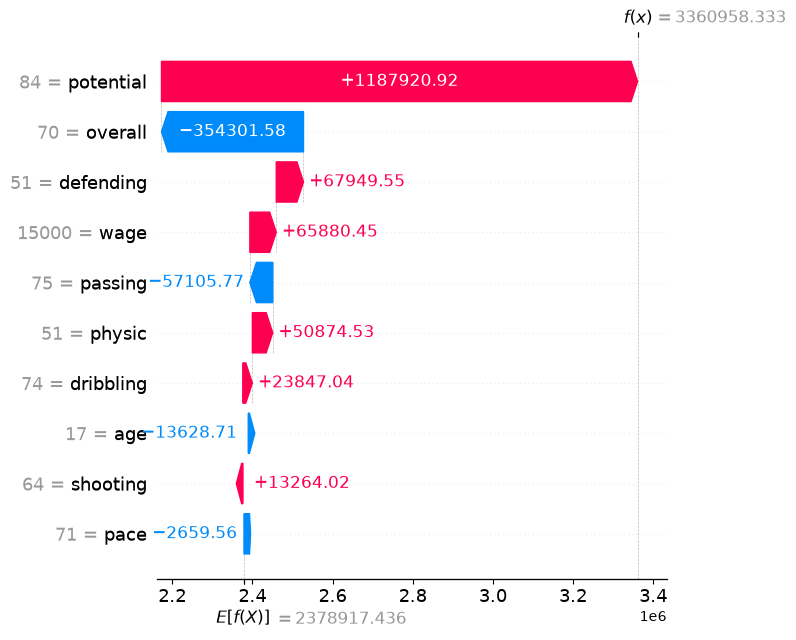

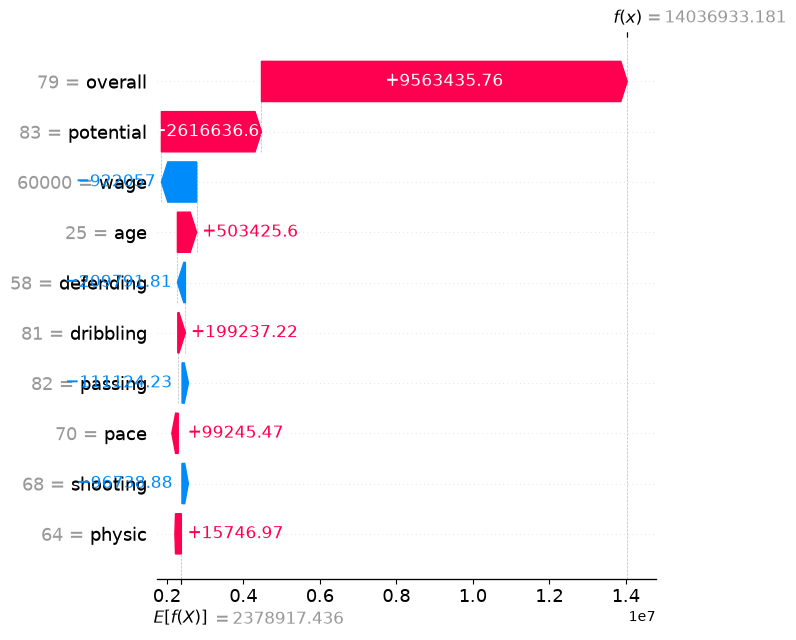

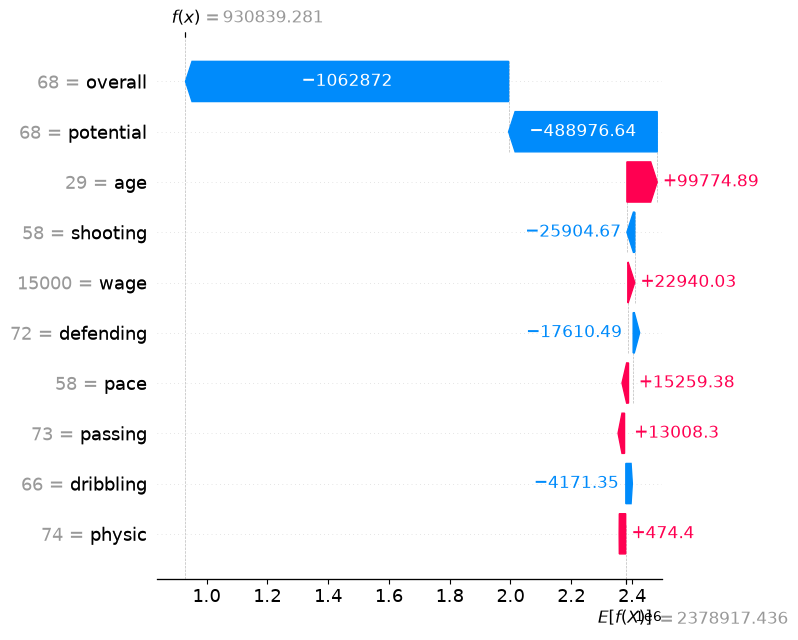

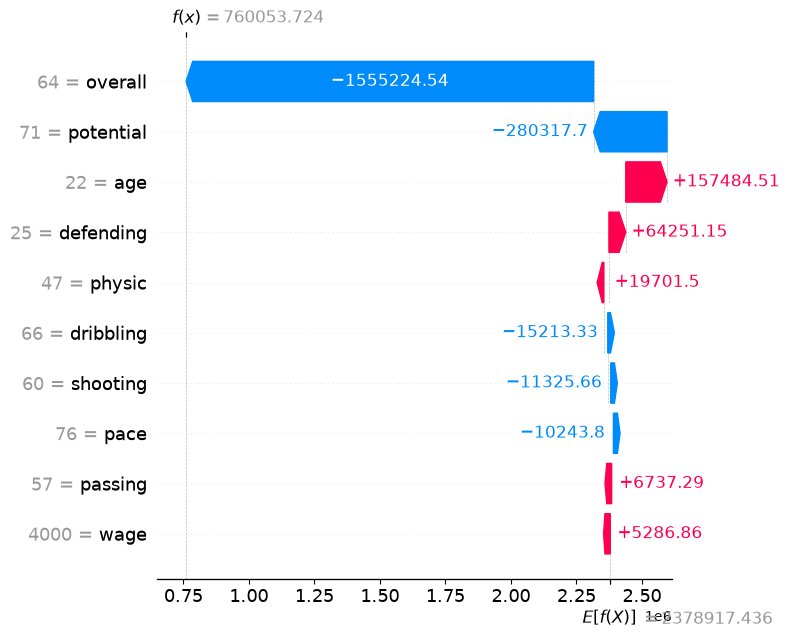

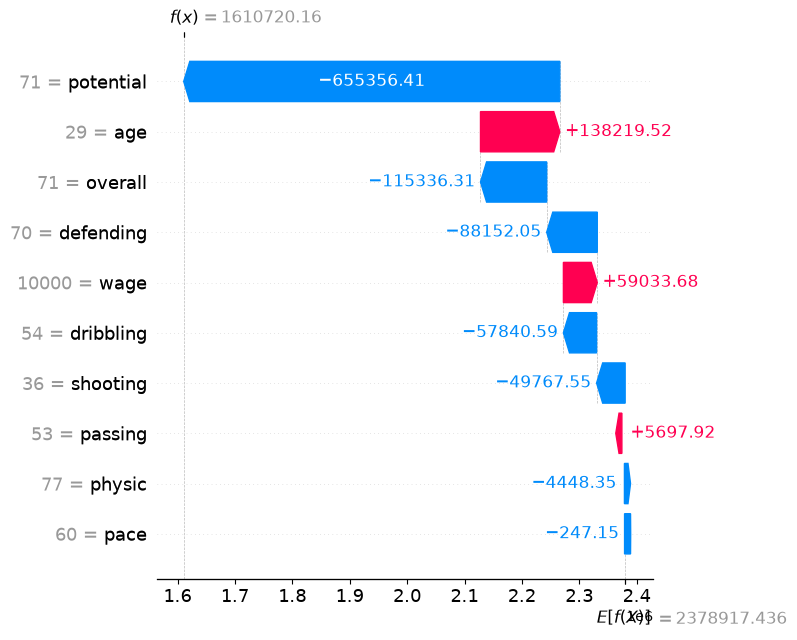

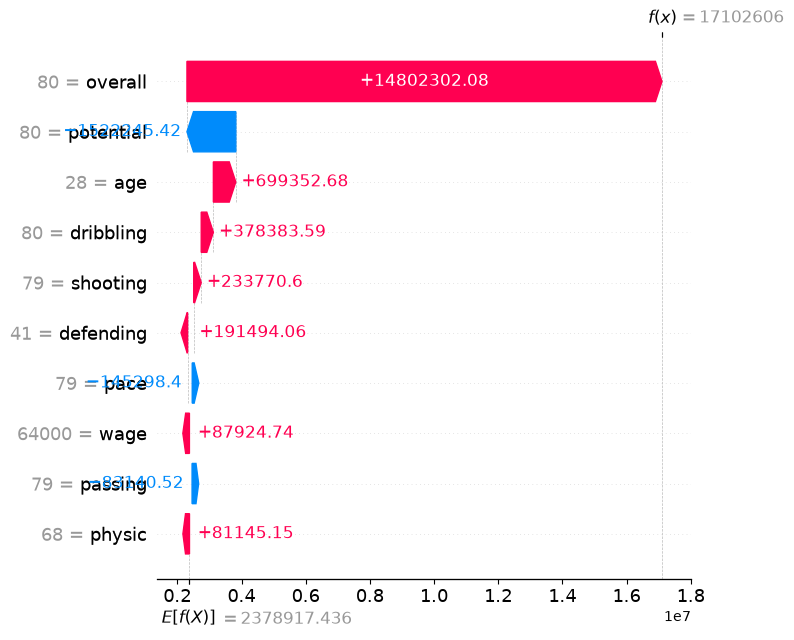

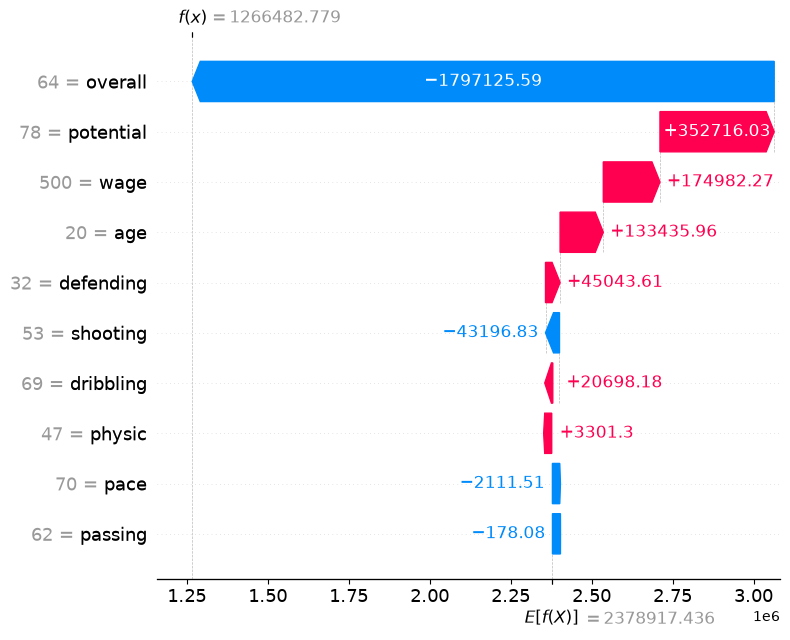

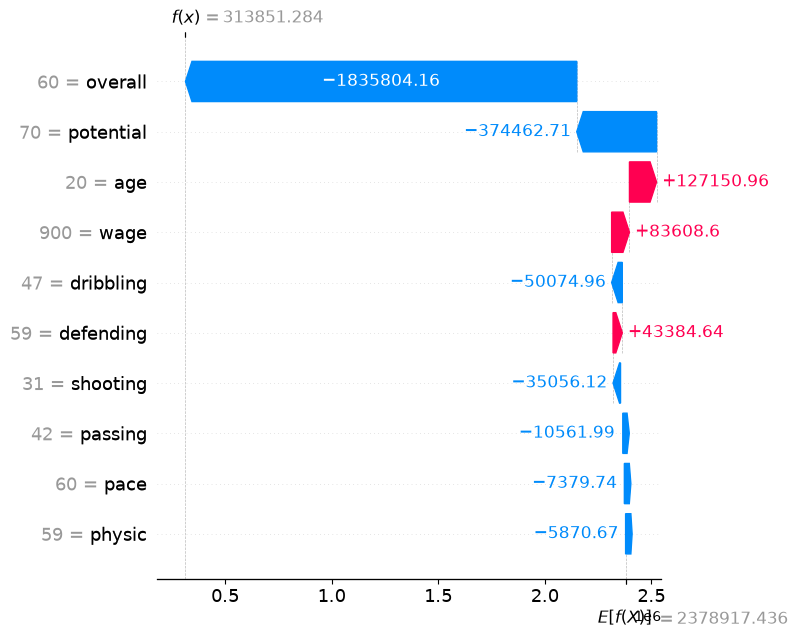

In [35]:
N_PLAYERS = 10

for i in range(N_PLAYERS):

    plt.figure(figsize=(10, 8))

    shap.plots.waterfall(
        shap_values[i],
        max_display=15,
        show=False,
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"waterfall_player_{i+1:03d}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

## 13. Mean Absolute SHAP Values ##

In [39]:
importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
})

importance = importance.sort_values(
    "mean_abs_shap",
    ascending=False,
)

importance

,feature,mean_abs_shap
1,overall,2.297609e+06
2,potential,5.581386e+05
0,age,2.042478e+05
9,wage,9.844644e+04
7,defending,7.868654e+04
4,shooting,5.582782e+04
6,dribbling,5.307711e+04
3,pace,2.218558e+04
8,physic,1.976408e+04
5,passing,1.871889e+04


## 14. Save SHAP Importance ##

In [41]:
importance.to_csv(
    TABLES_DIR / "shap_feature_importance.csv",
    index=False,
)

## Conclusions

- Identify the most influential features.
- Compare SHAP importance with Random Forest feature importance.
- Examine local explanations for individual players.

### Next

Proceed to **Notebook 09 — Player Similarity Engine**.